# Lab 11. Vision Language Action Models.

Basically, traditional Computer Vision focuses on perception (classifying images, detecting objects), while traditional Robotics focuses on control (moving motors, planning paths). It looks very promising to combine those concepts together to design such advanced robotics with wide rang of tasks it could perform with some respectable quality and time. In that sense Vision-Language-Action (VLA) models bridge these fields. They take an image (vision) and a text instruction (language) and directly output robot control commands (action).

**Vision-Language-Action (VLA)** models - a paradigm shift in robotics where a single neural network processes visual observations and language commands to directly output **robot actions**. Unlike traditional modular pipelines, VLAs leverage web-scale pretraining to achieve two main goals:

- unprecedented generalization
- zero-shot reasoning capabilities

If we look at the classical approach usually we have tried to construct a pipeline with separate stages consisting independently designed solutions. What's problem with that? Obviously, each module is trained separately could accumulate errors. The other thing is how to assess progress in that sense?

Such pipeline could look like:

### Camera → Object Detector → Motion Planner → Controller → Actions

VLA changes such paradigm to a more specialized context is that actions can be treated as **another language** - specifically discretized into tokens and predicted alongside text tokens in a standard language model architecture. By tokenizing actions, we can train a Large Language Model (LLM) backbone to predict actions just like it predicts the next word in a sentence.

### Camera + Text → [VLA Model] → Actions

**Input:** RGB Image + Natural Language Instruction (e.g., "Pick up the apple")

**Output:** Action Tokens (e.g., joint angles, end-effector velocities, gripper open/close)

**Core Idea:** Treat robot actions as a "language." By tokenizing actions, we can train a Large Language Model (LLM) backbone to predict actions just like it predicts the next word in a sentence and we get something like:

### Action = [terminate, x, y, z, rot_x, rot_y, rot_z, gripper]




## Robotic Transformer (RT-2)

<img src="https://drive.google.com/uc?id=1HPCJdjZ4hTzYn2MV4flhR2oY4anvU4Cy" width="800"/>

Focused on:

- Reuse pretrained vision-language model weights without architectural changes (PaLI-X or PaLM-E)
- Output both natural language and robot actions from the same model
- Leverage the "world knowledge" from web-scale pretraining

VLMs already contain rich knowledge about object properties, spatial relationships, and even rudimentary physics. By exposing this knowledge to robotic actions during fine-tuning, RT-2 enables emergent capabilities not present in the robot training data.

BUT: directly applying such models to robotic tasks is also diﬃcult: such models reason about semantics, labels, and textual prompts, whereas robots require grounded low-level actions, such **as Cartesian end-eﬀector commands**.

To enable vision-language models to control a robot, they must be trained to output actions. We can take a direct approach to this problem, representing actions as tokens in the model’s output, which are treated in the same way as language tokens.

Authors applied something called **co-fine-tuning** robotics data with the original web data instead of naïve finetuning on robot data only. It is noticed that co-fine-tuning leads to more generalizable policies since the policies are exposed to both abstract visual concepts from web scale data and low level robot
actions during fine-tuning, instead of just robot actions.

WHY? catastrophic forgetting - the model losing its web-scale knowledge when fine-tuned on robot data.

<img src="https://lh3.googleusercontent.com/wS51jyqW2T7T_m14tD2kn4pg86isQ1i7kusjlkQC-OktXdDgz-2iG4m_oZB8aFNmulk5ckURCxItJ1yWMVX54uU5k1WshHFKiqbhmNjlQmtgeN-O=w2880-rw-lo" width="800"/>

To ensure that RT-2 outputs valid action tokens during decoding, we constrain its output vocabulary via only sampling valid action tokens when the model is prompted with a robot-action task, whereas the model is still allowed to output the full range of natural language tokens on standard vision-language tasks.

### Importance of architecture:

- It demonstrated **emergent semantic reasoning**. The robot could perform tasks like "pick up the number closest to 3" by reading numbers in the environment, a capability not present in the robotics training data alone

- **Action Tokenization**: Continuous robot actions are discretized into bins (e.g., -1.0 to 1.0 mapped to integers 0-255) and treated as text tokens. In some sense model is able to orientate in spacial tasks.

### Main limitations
- It cannot learn new motions beyond the skills present in its training data.
- It excels at semantic generalization (recognizing novel objects) but not physical skill acquisition. It's using the "cerebrum" (high-level reasoning) for low-level control
- Not publicly available to check all provided statements

**Prediction vector**

<img src="https://drive.google.com/uc?id=1zZ8dSim3ez1kq4_OOIiAcaUA7SgVc9hM" width="800"/>

The string starts with a flag that indicates whether to continue or terminate the current episode, without executing the subsequent commands, and follows with the commands to change position and rotation of the end-effector, as well as the desired extension of the robot gripper.

An example of such a string could be a sequence of robot action token numbers, e.g.“1 128 91 241 5 101 127 217”.

## OpenVLA

Initial idea was to create an open-source model for democratizing research in this space. It allows the community to experiment with VLA fine-tuning, domain adaptation, and efficiency improvements. This model proves that you don't need a proprietary giant model to achieve strong VLA performance.

OpenVLA is designed to enhance the way robots learn, reason, and execute tasks through visual and language inputs. OpenVLA is a 7 billion parameter model, that is trained on 970,000 trajectories from a large-scale robotic dataset, [Open-X embodiment dataset](https://robotics-transformer-x.github.io).

<img src="https://drive.google.com/uc?id=1ygCe2ct2sNzGsIVs5hHkXMeKHAgB_9-_" width="800"/>

**Fused visual encoder:**
The visual encoder layer combines two pre-trained models, DinoV2 and SigLIP. DinoV2 is a ViT model that extracts visual features from images using self-supervised learning techniques that helps to capture spatial relationships and geometric understanding. SigLIP is another vision model but it enhances spatial reasoning capabilities, e.g. understanding and distingushing"red cube" vs "blue sphere".

Both outputs are concatenated. These models process visual inputs to generate patch embeddings which hold contextual visual information about the task.


**MLP Projector:**
The projector layer serves as a bridge between the visual encoder and the large language model (LLM). It extracts the output embeddings from the visual encoder and converts it to compatible format. This step integrates the visual aspects with language processing.

**Large Language Model:**
OpenVLA used Llama 2 (7B) LLM as a backbone, this processes the projected embeddings to generate tokenized output actions. These tokens are decoded into continuous commands that are executed on the robot.

**Proprioception Projector:**
Specialized MLP that takes raw robot state data and projects it into the same high-dimensional space as the visual and language tokens . This allows the main LLM (Llama 2) to process all inputs—what the robot sees, what it's been told, and what its own body is doing—in a unified representation.

**Action De-Tokenizer::**
The de-tokenizer performs the critical task of reconstructing continuous actions from discrete token predicted by the Transformer model back into continuous, low-level motor commands (joint positions, velocities, or end-effector poses) for a robot's action space (positional/rotational displacement + gripper state).

**Main contribution:**
Researchers stated that OpenVLA seems to be promising for zero-shot tasks, there are instances where it is not feasible to use the open-sourced model for certain tasks. Thus, finetuning the model with expert data in custom scenes come into the play. OpenVLA is designed for easy finetuning, allowing it to adapt to new tasks and environments efficiently. OpenVLA can be finetuned using low-rank adaptation (LoRA) on consumer-grade GPUs within a day. This reduces the high GPU compute need and cutting down the need to train a model from scratch.

## Let's make a simple example

In [2]:
!pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0


In [3]:
!pip install "numpy<2.0"

Restart kernel...

In [5]:
!pip install timm==0.9.10
!pip install tokenizers==0.19.1
!pip install torch>=2.2.0
!pip install torchvision>=0.16.0
!pip install transformers==4.40.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.1 MB/s eta 0:00:00
  Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 45.2 MB/s eta 0:00:00
Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl (530.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 42.4 MB/s eta 0:00:00
  Attempting uninstall: timm
    Found existing installation: timm 1.0.25
    Uninstalling timm-1.0.25:
      Successfully uninstalled timm-1.0.25


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 55.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.
transformers 5.0.0 requires tokenizers<=0.23.0,>=0.22.0, but you have tokenizers 0.19.1 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 91.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.1 which is incompatible.


In [1]:
import torch
from transformers import AutoModelForVision2Seq, AutoProcessor
import requests
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt
from transformers import BitsAndBytesConfig

In [2]:
MODEL_ID = "openvla/openvla-7b"

In [3]:
def load_model(model_id):

    processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
    model = AutoModelForVision2Seq.from_pretrained(
        "openvla/openvla-7b",
        torch_dtype=torch.bfloat16,
        low_cpu_mem_usage=True,
        trust_remote_code=True
    ).to("cuda:0")
    model.eval()

    return model, processor


model, processor = load_model(MODEL_ID)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possibl

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:
def visualize_action_space():
    """
    Visualize the discretized action space used by VLAs
    """
    # Typical 7-DoF action: [x, y, z, roll, pitch, yaw, gripper]
    # Each dimension discretized into 256 bins (0-255)

    fig, axes = plt.subplots(2, 4, figsize=(14, 6))
    axes = axes.flatten()

    action_names = ['X (forward/back)', 'Y (left/right)', 'Z (up/down)',
                    'Roll', 'Pitch', 'Yaw', 'Gripper']

    for i in range(7):
        # Discretization mapping: bin 0-255 → continuous range
        # Example ranges (robot-specific)
        ranges = {
            'x': (-0.5, 0.5),    # meters
            'y': (-0.5, 0.5),
            'z': (-0.2, 0.5),
            'roll': (-np.pi, np.pi),
            'pitch': (-np.pi/2, np.pi/2),
            'yaw': (-np.pi, np.pi),
            'gripper': (0, 1)     # 0=open, 1=closed
        }

        bins = np.arange(0, 256)
        low, high = ranges[action_names[i].lower().split()[0] if i < 6 else 'gripper']
        continuous = low + (bins / 255) * (high - low)

        axes[i].plot(bins, continuous)
        axes[i].set_xlabel('Token Value (0-255)')
        axes[i].set_ylabel('Continuous Value')
        axes[i].set_title(action_names[i])
        axes[i].grid(True)

    axes[7].axis('off')
    axes[7].text(0.1, 0.5,
                 "Action Tokenization:\n"
                 "Robot action = [term, x, y, z, roll, pitch, yaw, gripper]\n"
                 "Each dimension → 256 tokens\n"
                 "Termination token signals episode end",
                 fontsize=10, verticalalignment='center')

    plt.suptitle("VLA Action Space: Discretized Continuous Actions", fontsize=14)
    plt.tight_layout()
    plt.show()

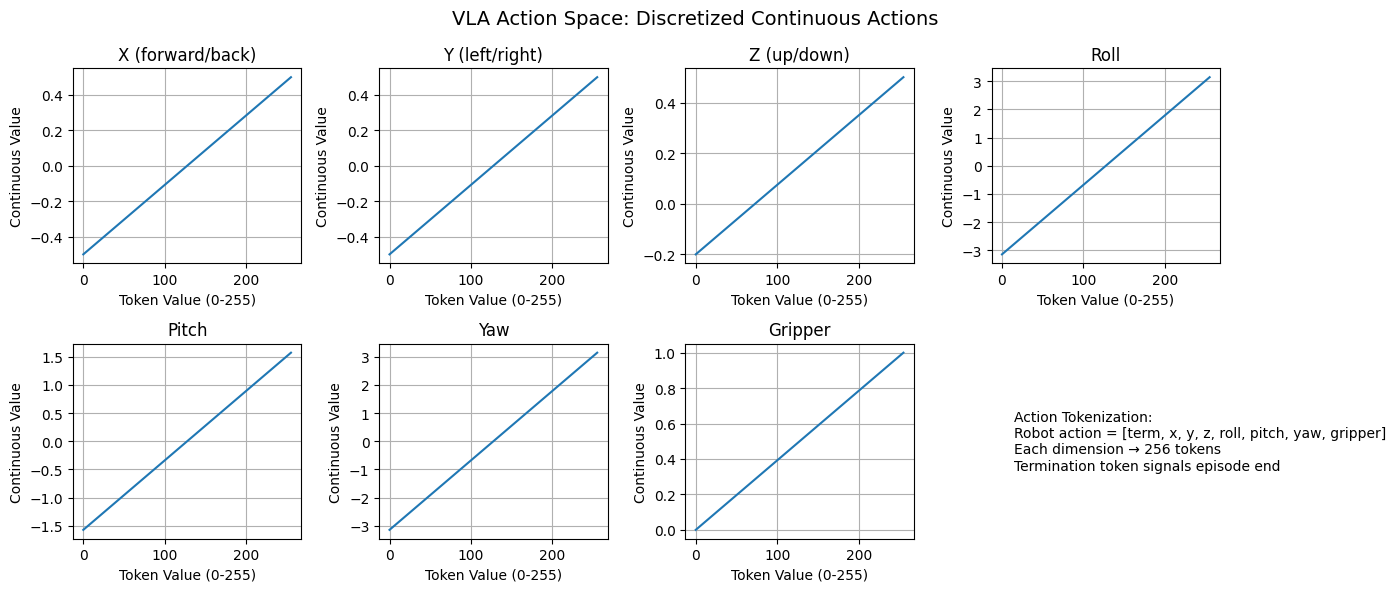

In [5]:
visualize_action_space()

In [6]:

# Create a Synthetic Observation (Matches the Provided Function)
def create_sample_observation():
    """Create a synthetic image of a red and blue block on a light blue background."""
    img = Image.new('RGB', (224, 224), color='lightblue')
    draw = ImageDraw.Draw(img)
    # Red square (left)
    draw.rectangle([50, 100, 100, 150], fill='red', outline='black')
    # Blue square (right)
    draw.rectangle([130, 100, 180, 150], fill='blue', outline='black')
    return img


# Action Prediction Function (Adjusted for OpenVLA)
def predict_action_openvla(model, processor, image, instruction):
    """
    Predict action tokens using OpenVLA.
    Returns: action tokens (list of ints) and decoded text string.
    """
    # OpenVLA prompt format
    prompt = f"In: What action should the robot take to {instruction.lower()}?\nOut:"

    # Process inputs: processor expects images and text separately
    inputs = processor(
        images=image,
        text=prompt,
        return_tensors="pt"
    ).to(model.device)

    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    if 'pixel_values' in inputs:
        inputs['pixel_values'] = inputs['pixel_values'].to(torch.bfloat16)

    # Generate action tokens
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,      # Action chunk length
            do_sample=False,        # Greedy decoding
        )

    # Extract the generated tokens (skip the input tokens)
    action_tokens = outputs[0].cpu().numpy()

    # Decode to text (the tokens correspond to action bins + special tokens)
    action_text = processor.decode(action_tokens, skip_special_tokens=True)

    return action_tokens, action_text


# Run an Example

# Create sample observation
image = create_sample_observation()
instruction = "pick up the red block"

action_tokens, action_text = predict_action_openvla(model, processor, image, instruction)

print("\n--- Results ---")
print(f"Instruction: {instruction}")
print(f"Predicted action tokens: {action_tokens}")
print(f"Decoded action string: {action_text}")

# Optional: show the image
image.show()

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 13.75 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 14.38 GiB is allocated by PyTorch, and 44.85 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

OOps! There is definitely a shortage of VRAM

You can check an example here as well:

https://www.kaggle.com/code/kirilly/openvla-f2906a

# Hometask

Imagine that you are prepraing your own lab where you want to present a VLA architecture. Your task is to prepare your own colab notebook. You are allowed to use this notebook as an example.

Requirements:
1. Choose one VLA architecture except those we've been gone through during this lab session (but you can take SmolVLA and other versions)

2. Exaplain what is it about, what idea stands behind its creation

3. What dataset used and why

4. Provide a code example of the model with action predictions (you can also make a comparison with RT-2 or OpenVLA)

5. You are allowed to help yourself by LLMs ONLY for code generation, but text should be written by yourself

6. Your explanation should be based on the original paper (provide a link)

GOOD LUCK!

In [ ]:
# YOUR CODE HERE